In [60]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [61]:
df = pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [62]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [66]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [67]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [68]:
df = df.drop(columns = ['RowNumber' ,'CustomerId', 'Surname'])

In [69]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [70]:
df = pd.get_dummies(df, columns = ['Geography', 'Gender'], drop_first = True).astype(int)

In [71]:
x = df.drop(columns = ['Exited'])
y = df['Exited']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 1)

In [72]:
x_train.shape

(8000, 11)

In [73]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [74]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [75]:
model = Sequential()
model.add(Dense(11, activation = 'sigmoid', input_dim=11))
model.add(Dense(11, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [76]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
model.compile(loss = 'binary_crossentropy', optimizer = 'Adam', metrics = ['accuracy'])

In [83]:
history = model.fit(x_train_scaled, y_train, epochs = 100, validation_split = 0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8636 - loss: 0.3279 - val_accuracy: 0.8587 - val_loss: 0.3364
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8667 - loss: 0.3187 - val_accuracy: 0.8550 - val_loss: 0.3373
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8634 - loss: 0.3228 - val_accuracy: 0.8556 - val_loss: 0.3365
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8687 - loss: 0.3212 - val_accuracy: 0.8556 - val_loss: 0.3376
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8636 - loss: 0.3312 - val_accuracy: 0.8550 - val_loss: 0.3371
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8619 - loss: 0.3213 - val_accuracy: 0.8544 - val_loss: 0.3373
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8660 - loss: 0.3196 - val_accuracy: 0.8569 - val_loss: 0.3376
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8686 - loss: 0.3216 - val_accu

In [79]:
model.layers[1].get_weights()

[array([[-0.3823858 ,  0.17054603, -0.45659193,  0.74078035, -1.0732895 ,
          0.7566191 , -0.07328599, -0.2485047 , -0.42356896,  0.11427625,
          0.2788734 ],
        [ 0.6760501 , -0.4257796 ,  0.20554237, -0.8014524 , -0.02085854,
         -0.17632931, -0.54555404,  0.60317135,  0.61348945, -0.4430162 ,
         -0.19598174],
        [-0.09309839, -1.3752961 ,  0.5784353 ,  0.48660538,  0.7526502 ,
          0.46955353, -0.14975357, -0.16139194,  0.02185824, -0.508685  ,
         -0.23786116],
        [ 0.46773258,  0.05693698,  1.0290195 ,  0.29493526,  0.3564516 ,
         -0.66358066,  0.43924832,  0.41798347,  0.6689704 , -0.0492219 ,
          0.6681934 ],
        [ 0.4179079 ,  0.5755056 ,  0.8671325 , -0.6450725 ,  0.7805929 ,
         -0.4469672 , -0.14180039, -0.2287609 ,  0.6166948 , -0.46047217,
         -0.18719737],
        [ 0.3808044 , -1.2154317 , -0.80341256, -1.0948402 , -0.16376548,
         -0.61087596,  0.12090307,  0.1985564 ,  0.4502972 , -0.2770245

In [80]:
y_log  = model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [81]:
y_pred = np.where(y_log>0.5, 1 ,0)

In [82]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.864

In [84]:
import matplotlib.pyplot as plt

In [85]:
history.history

{'accuracy': [0.8646875023841858,
  0.8634374737739563,
  0.8639062643051147,
  0.8648437261581421,
  0.8643749952316284,
  0.8643749952316284,
  0.864062488079071,
  0.8639062643051147,
  0.8634374737739563,
  0.8643749952316284,
  0.8646875023841858,
  0.8660937547683716,
  0.864062488079071,
  0.8635937571525574,
  0.866406261920929,
  0.864062488079071,
  0.8645312786102295,
  0.8670312762260437,
  0.8642187714576721,
  0.8643749952316284,
  0.8642187714576721,
  0.8653125166893005,
  0.8631250262260437,
  0.8657812476158142,
  0.866406261920929,
  0.8654687404632568,
  0.8642187714576721,
  0.864062488079071,
  0.8642187714576721,
  0.8660937547683716,
  0.8637499809265137,
  0.8667187690734863,
  0.8657812476158142,
  0.8654687404632568,
  0.8651562333106995,
  0.8648437261581421,
  0.8656250238418579,
  0.866406261920929,
  0.8654687404632568,
  0.8642187714576721,
  0.8657812476158142,
  0.8651562333106995,
  0.8665624856948853,
  0.8657812476158142,
  0.8671875,
  0.8662499785

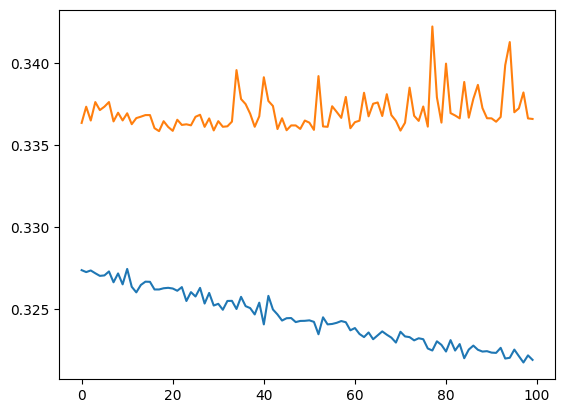

In [89]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

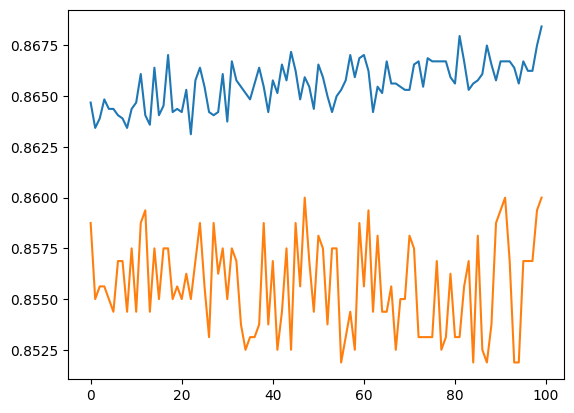

In [90]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])